# 📊 Assignment: Predicting 2024 Data Science Salaries Using Linear Regression

**Course**: Data Analytics with Python  
**Instructor**: Leonard Andrew Mesiera  
**Due Date**: October 22, 2025

## 🎯 Learning Objectives
By the end of this assignment, you will be able to:
- Load and explore a real-world dataset
- Prepare data for linear regression (feature engineering, encoding, cleaning)
- Train a simple linear regression model using `scikit-learn`
- Evaluate your model using metrics like R² and interpret results
- Make predictions for future years (e.g., 2024)

## 📁 Dataset
You are given the file: `Data Science Salary 2021 to 2023.csv`

This dataset contains salary information for data professionals from 2021 to 2023, including:
- `work_year`: The year the salary was recorded
- `experience_level`: EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `job_title`: e.g., Data Scientist, Data Analyst, etc.
- `salary_in_usd`: Salary converted to USD (this is your target variable)
- Other useful columns: `employment_type`, `company_location`, `company_size`

Your goal: **Predict average salaries for 2024** using linear regression.

## 🛠️ Part 1: Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Data Science Salary 2021 to 2023.csv')

# Display first few rows
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [2]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

1. How many unique job titles are there?
2. What is the average salary (`salary_in_usd`) per `work_year`?
3. Create a bar plot showing average salary by `experience_level`.

> 💡 Tip: Use `groupby()` and `mean()`.

In [17]:
# Your EDA code here
df['job_title'] = df['job_title'].astype('category')
uniqueJob = df['job_title'].nunique()
print(f'1. There are {uniqueJob} unique job titles')

1. There are 93 unique job titles


In [4]:
print('2. Average salary per working year:')
df.groupby('work_year')['salary_in_usd'].mean().round(2)

2. Average salary per working year:


work_year
2020     92302.63
2021     94087.21
2022    133379.51
2023    148954.56
Name: salary_in_usd, dtype: float64

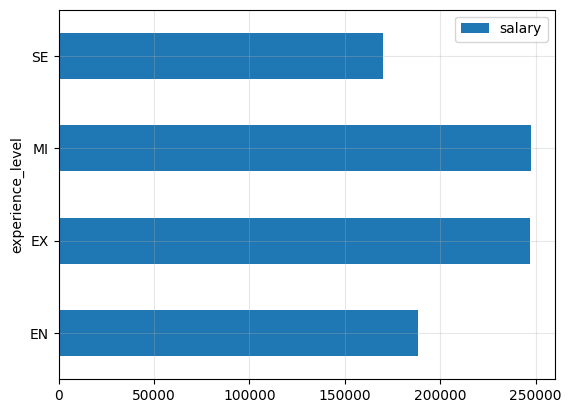

In [26]:
df.groupby('experience_level')['salary'].mean().reset_index().plot(kind='barh', x= 'experience_level')
plt.grid(alpha=0.3)
plt.show()

## 🧹 Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [28]:
# Example: Encode experience_level
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])

# Choose your features
features = ['work_year', 'experience_level_encoded']
X = df[features]
y = df['salary_in_usd']

# Optional: Add more features like job_title (try it!)
# But remember: too many categories can hurt performance

X.head()

,work_year,experience_level_encoded
0,2023,0
1,2023,0
2,2023,0
3,2023,0
4,2023,0


## 📈 Part 4: Train a Linear Regression Model

In [29]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [32]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size,experience_level_encoded
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L,0
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L,0
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L,0
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L,0
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L,0
5,2023,EN,FT,Applied Scientist,110680,USD,110680,US,L,0
6,2023,EN,FT,Machine Learning Engineer,163196,USD,163196,US,M,0
7,2023,EN,FT,Machine Learning Engineer,145885,USD,145885,US,M,0
8,2023,EN,FT,Research Scientist,220000,USD,220000,US,L,0
9,2023,EN,FT,Data Engineer,85000,USD,85000,US,M,0


In [43]:
# Map experience levels to encoded values (check your LabelEncoder!)
# Example: EN=0, MI=1, SE=2, EX=3 (confirm with `le.classes_`)
df['employment_type_encoded'] = le.fit_transform(df['employment_type'])


future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})


# Predict
predicted_salaries = model.predict(future_data)

# Display results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
results

features = ['work_year', 'employment_type_encoded']
X = df[features]
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


In [37]:
df['employment_type'].unique()

array(['FT', 'PT', 'CT', 'FL'], dtype=object)

In [45]:
# RETRAIN NEW MODEL BASED ON EMPLOYMENT TYPE
features = ['work_year', 'employment_type_encoded']
X = df[features]
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

future_data_employmentType = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'employment_type_encoded': [0, 1, 2, 3] #'FT', 'PT', 'CT', 'FL'
})

predicted_salaries = model.predict(future_data_employmentType)

model = pd.DataFrame({
    'Employment Type': ['Full-time', 'Part-time', 'Contract', 'Freelance'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
model


,Employment Type,Predicted 2024 Salary (USD)
0,Full-time,202276.881204
1,Part-time,186374.273585
2,Contract,170471.665967
3,Freelance,154569.058348


## 📝 Part 6: Reflection (Answer in a Markdown Cell)

1. Does your model make reasonable predictions? Why or why not?
2. What are the limitations of using only `work_year` and `experience_level`?
3. How could you improve this model? (Think: more features, better encoding, etc.)
4. Why is **R² not enough** to trust your predictions?

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

<p>1. Does your model make reasonable predictions? Why or why not?<br><b>I guess not. The predictions follow the linear trend learned from 2021–2023 but are likely unreliable because the model uses only year and one encoded categorical feature.</b></p>

<p>2. What are the limitations of using only `work_year` and `experience_level`?  <br>
<b>It leaves out crucial predictors, such as employment type, company size, job title, and location.</b></p>

<p>How could you improve this model? (Think: more features, better encoding, etc.)  <br>
<b>Maybe including features like company_location, company_size, employment_type, and job_title.</b> </p>

<p>4. Why is R² not enough to trust your predictions?  <br>
<b>Because I guess it only tells us how much of the variation in the dependent variables are explained by our independent variable. </b></p>

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀